Прогнозирование временных рядов

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns

In [205]:
df = pd.read_excel('Test.xlsm')


Загружаем данные и преобразуем в датафрейм 

In [206]:
all_data = []

headers = df.iloc[0:0]

for i in range(0, len(df)):
    row_data = df.iloc[i, 0].split(',')
    all_data.append(row_data)

result_df = pd.DataFrame(all_data)

In [207]:
result_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,615,1.3362780347913328,4,2023-09-02 20:30:00,1638.3247019999997,66.51456310679617,1.2174757281553403,0.030886518607078993,3.6525475120128714,6.170192806498389,0.00132,1.3475265904958134,71.05279999999999,0.15162912,0.08112000000000005,1.0368279644992553
1,616,1.4585315304836697,5,2023-09-03 00:30:00,8216.925822,61.25304442036837,1.197009750812568,0.03227297548363277,3.6507833181269995,5.957700548427973,0.00132,1.2859580269057629,78.0556,0.13566815999999998,0.095316,1.0164461048208413
2,617,1.1279507931488253,4,2023-09-03 03:30:00,13117.140245999999,64.06666666666663,1.1776470588235295,0.032930141950372534,3.644152732199956,5.881832208979236,0.00132,1.5922488634894514,70.47634999999998,0.1782307199999996,0.10803709090909086,1.0394923036060135
3,618,0.9887584997678088,2,2023-09-03 05:30:00,16509.758579999998,60.27131004366806,1.1672489082969435,0.03156738965946021,3.681289885435212,6.300830474726579,0.00132,1.3600206075485712,68.25594999999998,0.1383283199999996,0.08093563636363643,1.0323539746552433
4,619,1.7737951770393852,4,2023-09-03 08:30:00,1646.7588059999998,65.24213973799127,1.412227074235811,0.030643815132535345,3.673913022303185,6.45193617225762,0.00132,1.486951205782781,67.1244,0.1383283199999996,0.06508036363636369,1.072045651936284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,764,4.032191368437019,5,2023-09-21 20:30:00,1960.3335149999998,64.38000000000002,2.562352941176477,0.13822382045329962,7.529485408187505,4.126173116559141,0.0024288,1.4836220583453081,52.264799999999994,0.2766566400000004,0.23045454545454527,1.209305893087211
150,765,4.360660856838021,1,2023-09-22 00:30:00,9399.0614445,61.032969432314374,2.663056768558956,0.1312857655780264,7.303860428915663,4.547765869905337,0.0022572,1.4763914148594564,61.722849999999994,0.3325200000000004,0.18639163636363645,1.2426216073648326
151,766,4.287594527996933,5,2023-09-22 03:30:00,15282.169875,56.304,2.664364820846903,0.1351970819397121,7.364977871786491,4.593129961530057,0.0022836,1.4531489876311205,60.292399999999994,0.24207455999999958,0.16205563636363596,1.2489972653978931
152,767,4.2805312817363435,5,2023-09-22 05:30:00,19198.621133999997,60.772868047982485,2.675986913849515,0.1351970819397121,7.364977871786491,4.593129961530057,0.0024948,1.4368099877236395,49.532,0.24207455999999958,0.14749090909090956,1.2456871223258272


In [208]:
# формат даты-времени 
time_format = '%H:%M:%S' # ЧАСЫ-МИНУТЫ-СЕКУНДЫ
date_format = '%Y-%m-%d' # ГОД-МЕСЯЦ-ДЕНЬ
datetime_format = '%Y-%m-%d %H:%M:%S'

In [209]:
#Преобразуем дату и делаем индексом датасета
result = result_df.set_index(pd.to_datetime(result_df[3].values, format=datetime_format)).drop(labels=[3], axis=1)
result.rename(columns={15: 'Target', 0: "№ наблюдения"}, inplace=True)
for ind, column in enumerate(result.columns[1:17]):
    result.rename(columns={ind+1: f'Feature №{ind+1}'}, inplace=True)



In [211]:
# узнаем текущую частоту индекса
print(result.index.inferred_freq) # -> None


None


 Неравномерные интервалы между датами

In [213]:
#Посмотрим основные стат покзаатели датасета

result.describe()

,№ наблюдения,Feature №1,Feature №2,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Target
count,154,154,154,154,154,154,154,154,154,154,154,154,154,154,154
unique,154,154,5,138,138,129,152,152,152,95,154,149,84,141,154
top,615,1.3362780347913328,4,1960.3335149999998,62.549606986899505,2.665967213114753,0.1351970819397121,7.364977871786491,4.593129961530057,0.00132,1.3475265904958134,70.47634999999998,0.2819769599999996,0.13089818181818175,1.0368279644992553
freq,1,1,45,3,2,3,3,3,3,12,1,2,5,3,1


Видим, что в датасете некорректный тип данных. Необходимо провести преобразование типов

In [214]:
result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 154 entries, 2023-09-02 20:30:00 to 2023-09-22 08:30:00
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   № наблюдения  154 non-null    object
 1   Feature №1    154 non-null    object
 2   Feature №2    154 non-null    object
 3   Feature №4    154 non-null    object
 4   Feature №5    154 non-null    object
 5   Feature №6    154 non-null    object
 6   Feature №7    154 non-null    object
 7   Feature №8    154 non-null    object
 8   Feature №9    154 non-null    object
 9   Feature №10   154 non-null    object
 10  Feature №11   154 non-null    object
 11  Feature №12   154 non-null    object
 12  Feature №13   154 non-null    object
 13  Feature №14   154 non-null    object
 14  Target        154 non-null    object
dtypes: object(15)
memory usage: 19.2+ KB


In [215]:
#Преобразуем тип данных в вещественное число
result[result.columns] = result[result.columns].astype('float64')

In [255]:
#Проверяем 
result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 154 entries, 2023-09-02 20:30:00 to 2023-09-22 08:30:00
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   № наблюдения  154 non-null    float64
 1   Feature №1    154 non-null    float64
 2   Feature №2    154 non-null    float64
 3   Feature №4    154 non-null    float64
 4   Feature №5    154 non-null    float64
 5   Feature №6    154 non-null    float64
 6   Feature №7    154 non-null    float64
 7   Feature №8    154 non-null    float64
 8   Feature №9    154 non-null    float64
 9   Feature №10   154 non-null    float64
 10  Feature №11   154 non-null    float64
 11  Feature №12   154 non-null    float64
 12  Feature №13   154 non-null    float64
 13  Feature №14   154 non-null    float64
 14  Target        154 non-null    float64
dtypes: float64(15)
memory usage: 19.2 KB


In [256]:
#Cтроим повторно описание основных стат показателей датасета
result.describe()

,№ наблюдения,Feature №1,Feature №2,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Target
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,691.500000,4.554740,3.071429,10465.979294,61.939569,2.729733,0.088669,7.475257,5.247315,0.002567,1.515171,62.620520,0.325756,0.168604,1.338536
std,44.600075,1.070427,1.451198,6116.989393,3.568592,0.452971,0.034839,1.101217,0.822308,0.001190,0.077428,11.088966,0.093379,0.068196,0.107031
min,615.000000,0.988758,1.000000,1540.864300,29.857574,1.167249,0.029844,3.644153,3.854330,0.001320,1.261358,30.701300,0.075549,0.020833,1.016446
25%,653.250000,4.278254,2.000000,1962.968372,61.033015,2.652196,0.058285,7.294428,4.654496,0.001944,1.477626,54.421150,0.281977,0.126335,1.315512
50%,691.500000,4.402410,3.000000,9810.099117,62.093839,2.677427,0.081122,7.708084,5.049736,0.002402,1.519035,63.548275,0.319219,0.163070,1.357152
75%,729.750000,4.586450,4.000000,15663.697150,63.251576,2.758881,0.125749,8.005187,5.785206,0.002812,1.562642,70.406962,0.366437,0.195932,1.399521
max,768.000000,7.458846,5.000000,19587.526009,72.772606,3.792838,0.161074,9.234828,7.285533,0.012540,1.764027,84.054950,0.896474,0.448004,1.505904


In [265]:
#Проведем ресемпл временных интервалов

frequencies = ['30T', '1H', '3H', '6H', '12H', '1D']


def choose_freq_time_series(data, freq):  
    freq_results = []
    data_to_cover = data
    for freq in frequencies:
        data_new = data_to_cover.resample(freq).mean()
        freq_results.append(data_new)
    return freq_results

sample_results = choose_freq_time_series(data=result, freq=frequencies)


title = []
for sample in sample_results:
    print(sample.shape[0], sample.index.inferred_freq)
    title.append(sample.index.inferred_freq)



937 30min
469 h
157 3h
79 6h
40 12h
21 D


/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_54607/2191557551.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data_new = data_to_cover.resample(freq).mean()
/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_54607/2191557551.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_new = data_to_cover.resample(freq).mean()


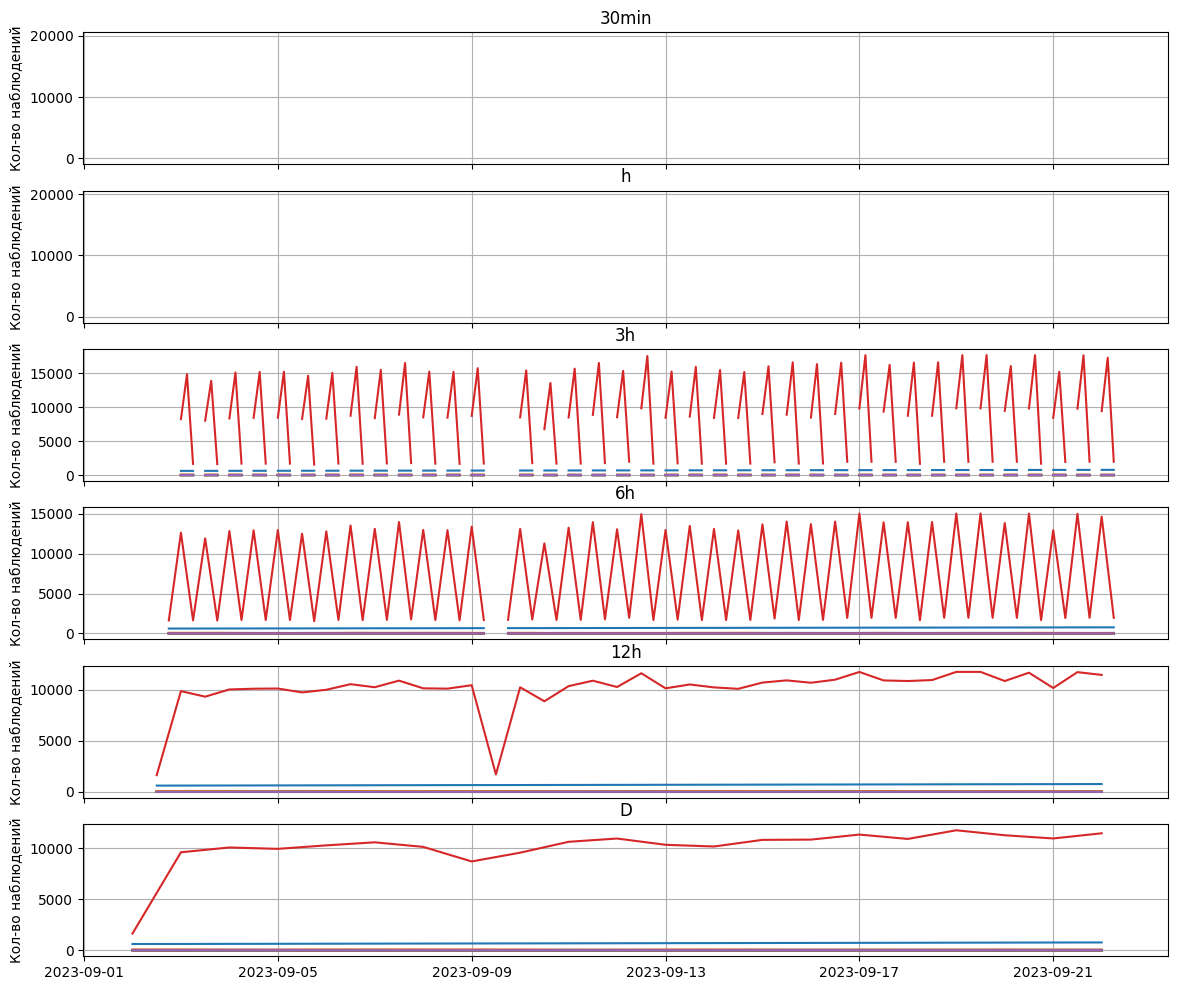

In [271]:
fig, axes = plt.subplots(len(sample_results), 1, figsize=(14, 12), sharex=True)

# в цикле отрисовываем графики
for ax, series, one_title in zip(axes, sample_results, title):
    ax.plot(series.index, series)
    ax.set_title(one_title)
    ax.set_ylabel('Кол-во наблюдений')
    ax.grid(True)
plt.show()

Выбираем семпл временного периода в днях!

In [274]:
result = sample_results[-1]
result.head(2)

,№ наблюдения,Feature №1,Feature №2,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Target
2023-09-02,615.0,1.336278,4.000,1638.324702,66.514563,1.217476,0.030887,3.652548,6.170193,0.00132,1.347527,71.052800,0.151629,0.08112,1.036828
2023-09-03,619.5,1.722003,3.375,9600.118878,62.807708,1.424856,0.031448,3.770055,6.315257,0.00132,1.378634,71.530506,0.150964,0.06621,1.054220


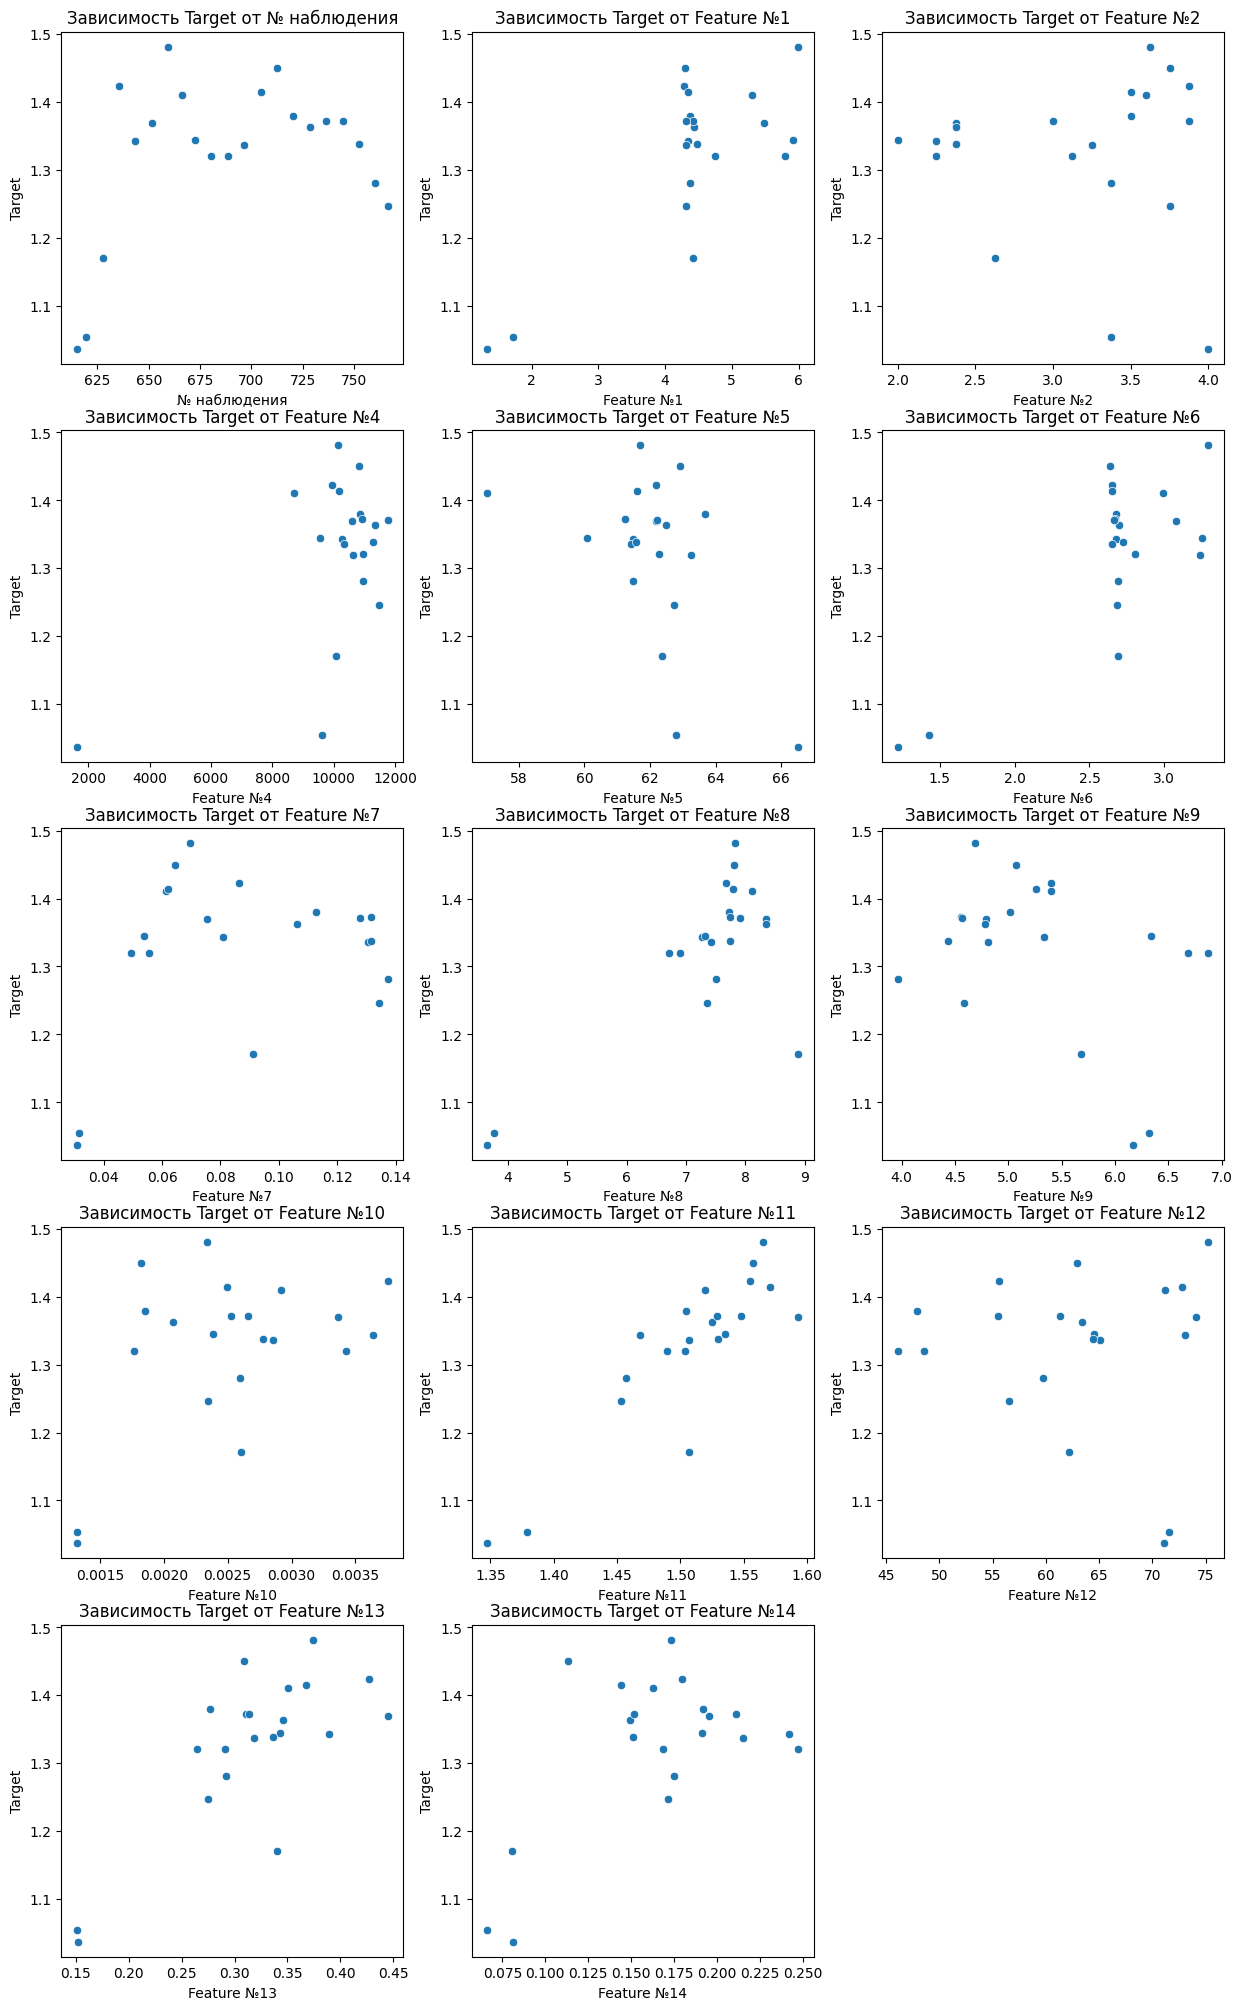

In [275]:
def plots_correlation_numeric_features_with_target(data, num_col):
    num_col = num_col.to_list()
    num_col.remove('Target')
    target = 'Target'
    n_cols = 3
    n_rows = (len(num_col) + n_cols) // 3
    plt.figure(figsize=(15,25))
    for i, feature in enumerate(num_col):
        plt.subplot(n_rows, n_cols, i+1)
        sns.scatterplot(data=data, x=feature, y=target)
        plt.xlabel(feature)
        plt.ylabel("Target")
        plt.title(f"Зависимость {target} от {feature}")   

plots_correlation_numeric_features_with_target(data=result, num_col=result.columns)

<Axes: >

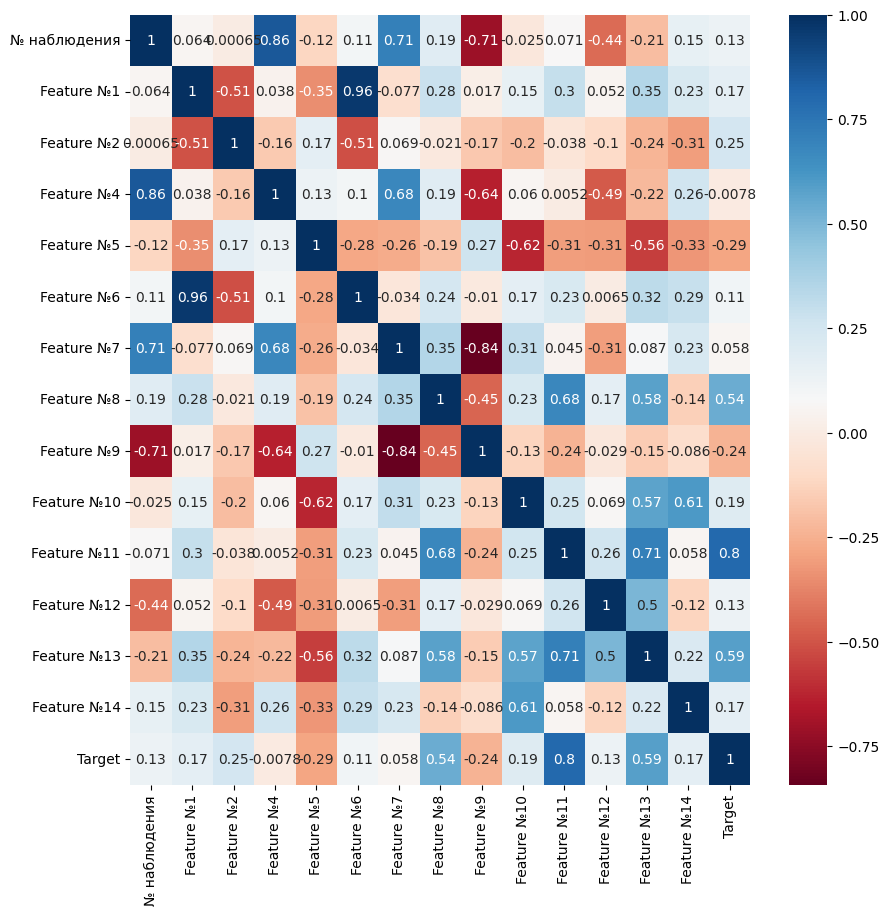

In [276]:
plt.figure(figsize=(10,10))
sns.heatmap(data=result.corr(method='spearman'), annot=True, cmap='RdBu')

Наблюдаем сильные линейные связи у признаков -  мультиколлениарность!

In [277]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def search_multicollinear(df, num_col):
    """Функция вычисляющая Фактор инфляции дисперсии (VIF) и сигнализирует о наличии и силы мультиколлинеарности у независимых фич"""
    df = df[num_col].drop(labels=['Target','№ наблюдения'], axis=1) # выбираем кол-ые признаки, удаляем таргет
    df = df.fillna(df.mean()) # обрабатываем пропуски в данных
    X_with_const = add_constant(df) #добавляем константу в датафрейм т.к. VIF не работает с пропусками
    X_features = X_with_const.columns  #определяем названия колонок фичей
    vif_df = pd.DataFrame() # формируем пустой датафрейм для организации расчетных  итоговых цифр 
    vif_df['feature'] = X_features # заполняем датафрейм названиями независимых фич
    vif_df['VIF'] = [variance_inflation_factor(X_with_const.values,i)  for i in range(X_with_const.shape[1])] #посредством list comprehension записываем итоговые VIF коэффициенты в датафрейм 
    #валидация итоговых результатов
    print('=================================================================')
    if vif_df.iloc[1:,:].max()[1] > 10:
        print("Присутствует сильная мультиколлинеарность")
    elif vif_df.iloc[1:,:].max()[1] < 10 and vif_df.iloc[1:,:].max()[1] > 5:
        print("Присутствует умеренная мультиколлинеарность")
    else:
        print("Мультиколлинеарность незначительная или отсутствует вовсе ")
    print('=================================================================')

    return vif_df # возвращаем VIF коэффициенты по каждой фиче


In [283]:
vif_feature = search_multicollinear(df=result, num_col=result.columns)
vif_feature

Присутствует сильная мультиколлинеарность


/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_54607/1364050096.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if vif_df.iloc[1:,:].max()[1] > 10:


,feature,VIF
0,const,15713.163708
1,Feature №1,810.850968
2,Feature №2,3.505685
3,Feature №4,6.161752
4,Feature №5,3.182782
5,Feature №6,967.757002
6,Feature №7,16.159218
7,Feature №8,14.117391
8,Feature №9,17.371746
9,Feature №10,7.890939


In [297]:
result

,№ наблюдения,Feature №1,Feature №2,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Target
2023-09-02,615.0,1.336278,4.000,1638.324702,66.514563,1.217476,0.030887,3.652548,6.170193,0.001320,1.347527,71.052800,0.151629,0.081120,1.036828
2023-09-03,619.5,1.722003,3.375,9600.118878,62.807708,1.424856,0.031448,3.770055,6.315257,0.001320,1.378634,71.530506,0.150964,0.066210,1.054220
2023-09-04,627.5,4.418343,2.625,10070.583742,62.380267,2.689985,0.091229,8.886171,5.684477,0.002602,1.506938,62.157856,0.340500,0.080890,1.170764
2023-09-05,635.5,4.284218,3.875,9935.147775,62.180474,2.653041,0.086326,7.671824,5.404238,0.003754,1.555095,55.600737,0.427288,0.179547,1.422999
2023-09-06,643.5,4.348677,2.250,10277.522727,61.483122,2.674951,0.080771,7.263712,5.336714,0.003642,1.467780,73.019669,0.389048,0.242323,1.343171
2023-09-07,651.5,5.480491,2.375,10575.788525,62.183932,3.078969,0.075398,8.341666,4.795131,0.003366,1.592920,74.111187,0.444912,0.195264,1.369697
2023-09-08,659.5,5.993255,3.625,10128.819309,61.700510,3.294624,0.069573,7.817941,4.686617,0.002336,1.564993,75.248075,0.373752,0.173394,1.481252
2023-09-09,666.0,5.301173,3.600,8702.194498,57.040925,2.993819,0.061488,8.102107,5.402492,0.002917,1.519210,71.193710,0.350609,0.162719,1.410522
2023-09-10,672.5,5.915700,2.000,9561.105142,60.075013,3.255417,0.053992,7.325687,6.333364,0.002386,1.535301,64.538381,0.343161,0.191346,1.344660
2023-09-11,680.5,5.797887,2.250,10625.471386,63.238153,3.235667,0.049334,6.712641,6.875519,0.001767,1.503457,46.062625,0.290955,0.168577,1.319871


In [301]:
#Удаляем признаки с высокой мультиколлениарностью
feature_to_drop = []

for i, feature in enumerate(vif_feature['feature'].to_list()[1:]):
    if vif_feature['VIF'][i+1] > 10:
        feature_to_drop.append(feature)

result.drop(labels=feature_to_drop, axis=1, inplace=True)

In [303]:
result.head(2)

,№ наблюдения,Feature №2,Feature №4,Feature №5,Feature №10,Feature №11,Feature №12,Feature №14,Target
2023-09-02,615.0,4.000,1638.324702,66.514563,0.00132,1.347527,71.052800,0.08112,1.036828
2023-09-03,619.5,3.375,9600.118878,62.807708,0.00132,1.378634,71.530506,0.06621,1.054220


In [304]:
tscv = TimeSeriesSplit(n_splits=2)

print("Простой TimeSeriesSplit (n_splits=3):")
for fold, (train_index, test_index) in enumerate(tscv.split(result)):
    print(f"Fold {fold + 1}:")
    print(f"  Train: indices {train_index[0]}..{train_index[-1]} (size: {len(train_index)})")
    print(f"  Test:  indices {test_index[0]}..{test_index[-1]} (size: {len(test_index)})")

Простой TimeSeriesSplit (n_splits=3):
Fold 1:
  Train: indices 0..6 (size: 7)
  Test:  indices 7..13 (size: 7)
Fold 2:
  Train: indices 0..13 (size: 14)
  Test:  indices 14..20 (size: 7)


Обучим простую линейную модель

In [351]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([('scaler', StandardScaler()),
                 ('model', Ridge(alpha=10))])

In [352]:
X = result.drop(labels=['Target'], axis=1)
y = result['Target']

X_train = X.iloc[train_index[0]:train_index[-1]]  
X_test = X.iloc[test_index[0]:test_index[-1]] 
  

y_train = y.iloc[train_index[0]:train_index[-1]]
y_test = y.iloc[test_index[0]:test_index[-1]]


In [353]:
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None


In [354]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [355]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error


def show_all_regressor_metrics(y_pred, y_test, title):
    print(f'============================={title}========================================')
    print(f"R2 - {r2_score(y_test, y_pred)}")
    print(f"MSE - {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE - {root_mean_squared_error(y_test, y_pred)}")
    print('=============================================================================')

In [356]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='Test')
show_all_regressor_metrics(y_pred=y_train_pred, y_test=y_train, title='Train')

=============================Test========================================
R2 - -1.0689247813095393
MSE - 0.0023887009661738173
RMSE - 0.04887433852415619
=============================Train========================================
R2 - 0.8283622668337413
MSE - 0.0030269284503041077
RMSE - 0.05501752857321117


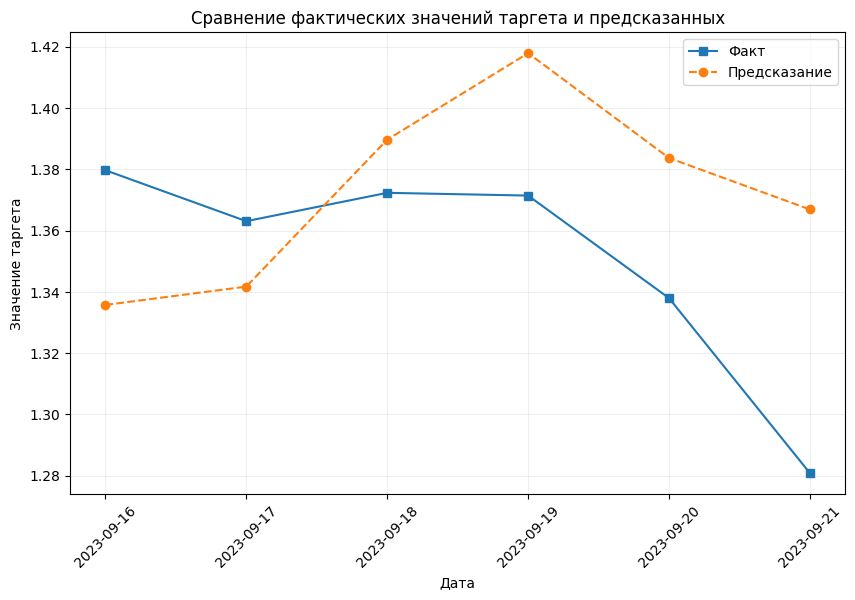

In [360]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(X_test.index, y_test, label='Факт',marker='s')
ax.plot(X_test.index, y_pred, label='Предсказание', marker='o', linestyle='--')
plt.title('Сравнение фактических значений таргета и предсказанных')
plt.xlabel('Дата')
plt.ylabel('Значение таргета')
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Модель сильно переобучена из-за чего коэф детерминации хуже предсказания средней.

- Не хватает данных для обучения
- Увеличить коэф регуляризации
- Применить более сильные модели (случайный лес, градиентный бустинг)